# Projet Machine Learning (Classification)

Durant ce projet on suivras les étapes suivantes : 
* Data engineering (nettoyage des données, normalisation, codage)
* Sélection et extraction des caractéristiques (Matrice de corrélation, ACP, t-SNE, …)
* Visualisation des caractéristiques
* Choix des modèles avec leur cross-validation
* Résultats / métriques (Classification : Matrice de confusion)

In [1]:
import os
import pandas as pd
import seaborn as sns

# Installation forcée de xgboost dans l'environnement du notebook
%pip install xgboost

nom_fichier = "penguins.csv"

# Vérification si le fichier existe déjà
if os.path.exists(nom_fichier):
    # Si le fichier existe, on le charge directement depuis le disque
    df = pd.read_csv(nom_fichier)
    print(
        f"Le fichier '{nom_fichier}' existe déjà. Chargement local réussi ({len(df)} lignes) !"
    )
else:
    # Si le fichier n'existe pas, on le télécharge via Seaborn et on le sauvegarde
    print(
        f"'{nom_fichier}' introuvable. Téléchargement depuis Seaborn en cours..."
    )
    df = sns.load_dataset("penguins")
    df.to_csv(nom_fichier, index=False)
    print(f"Fichier '{nom_fichier}' créé avec succès ({len(df)} lignes) !")


Note: you may need to restart the kernel to use updated packages.
'penguins.csv' introuvable. Téléchargement depuis Seaborn en cours...
Fichier 'penguins.csv' créé avec succès (344 lignes) !


In [2]:
# on visualise les donnnées avec "head() pour les 15 premières lignes"
df.head(15)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


1. Data engineering (nettoyage des données, normalisation, codage)

On peut constater que l'on va avoir besoin de nétoyer la basse de donnée. On va supprimer les lignes auquel il manque des variables et s'assurer qu'il n'y a pas d'outliers que l'on supprimera si besoin. (mieux expliqué)

In [3]:
# On commence par supprimer les lignes avec une ou des valeurs manquantes
import numpy as np
import seaborn as sns
import pandas as pd

# --- Ton code de départ ---
df = sns.load_dataset("penguins")

# 1. NETTOYAGE DES DONNÉES


# A. Suppression des lignes avec des valeurs manquantes (NaN)
df_clean = df.dropna().copy()
print(
    f"Après suppression des NaN : {len(df_clean)} lignes restantes (sur {len(df)} initiales)."
)


# B. Contrôle et traitement des valeurs aberrantes (Méthode IQR)
# On applique l'IQR uniquement sur les colonnes numériques
num_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

print("\n--- Analyse des valeurs aberrantes (IQR) ---")
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # Définition des bornes
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identification des outliers
    outliers = df_clean[
        (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    ]
    print(f"Borne pour {col}: [{lower_bound:.2f} ; {upper_bound:.2f}]")
    print(f"-> Nombre d'outliers détectés dans {col} : {len(outliers)}")

    # Optionnel : Filtrer pour supprimer les outliers
    # df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"\nTaille finale du dataset après nettoyage : {len(df_clean)} lignes.")

Après suppression des NaN : 333 lignes restantes (sur 344 initiales).

--- Analyse des valeurs aberrantes (IQR) ---
Borne pour bill_length_mm: [25.85 ; 62.25]
-> Nombre d'outliers détectés dans bill_length_mm : 0
Borne pour bill_depth_mm: [10.95 ; 23.35]
-> Nombre d'outliers détectés dans bill_depth_mm : 0
Borne pour flipper_length_mm: [155.50 ; 247.50]
-> Nombre d'outliers détectés dans flipper_length_mm : 0
Borne pour body_mass_g: [1712.50 ; 6612.50]
-> Nombre d'outliers détectés dans body_mass_g : 0

Taille finale du dataset après nettoyage : 333 lignes.


Pour la suite on fait le Codage (Encoding) et la Normalisation (Scaling)

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler


# 2. SEPARATION CIBLE (y) ET CARACTÉRISTIQUES (X)


# y est la variable qu'on veut prédire (l'espèce)
y_raw = df_clean["species"]

# X contient toutes les autres caractéristiques (on enlève 'species')
X_raw = df_clean.drop(columns=["species"])


# 3. CODAGE (ENCODING)

# A. Encodage de la cible y (Label Encoding : Adelie->0, Chinstrap->1, Gentoo->2)
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(
    f"Classes encodées pour la cible : {dict(zip(le.classes_, le.transform(le.classes_)))}"
)

# B. Encodage des variables catégorielles de X (One-Hot Encoding pour 'island' et 'sex')
# drop_first=True permet d'éviter le piège de la colinéarité (dummy variable trap)
X_encoded = pd.get_dummies(X_raw, columns=["island", "sex"], drop_first=True)


# 4. NORMALISATION (SCALING)

cols_to_scale = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

# Copie du dataframe encodé pour appliquer la normalisation
X = X_encoded.copy()

# Application du StandardScaler (Moyenne = 0, Écart-type = 1)
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

print("\n--- Aperçu des caractéristiques (X) après Encodage et Normalisation ---")
print(X.head())

Classes encodées pour la cible : {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}

--- Aperçu des caractéristiques (X) après Encodage et Normalisation ---
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0       -0.896042       0.780732          -1.426752    -0.568475   
1       -0.822788       0.119584          -1.069474    -0.506286   
2       -0.676280       0.424729          -0.426373    -1.190361   
4       -1.335566       1.085877          -0.569284    -0.941606   
5       -0.859415       1.747026          -0.783651    -0.692852   

   island_Dream  island_Torgersen  sex_Male  
0         False              True      True  
1         False              True     False  
2         False              True     False  
4         False              True     False  
5         False              True      True  


Ici j'ai décidé de supprimé les lignes des données manquante car la base de donnée sembles assez grande pour ce le permetre.

2. Sélection, extraction et visualisation des caractéristiques


--- Génération du Pairplot ---


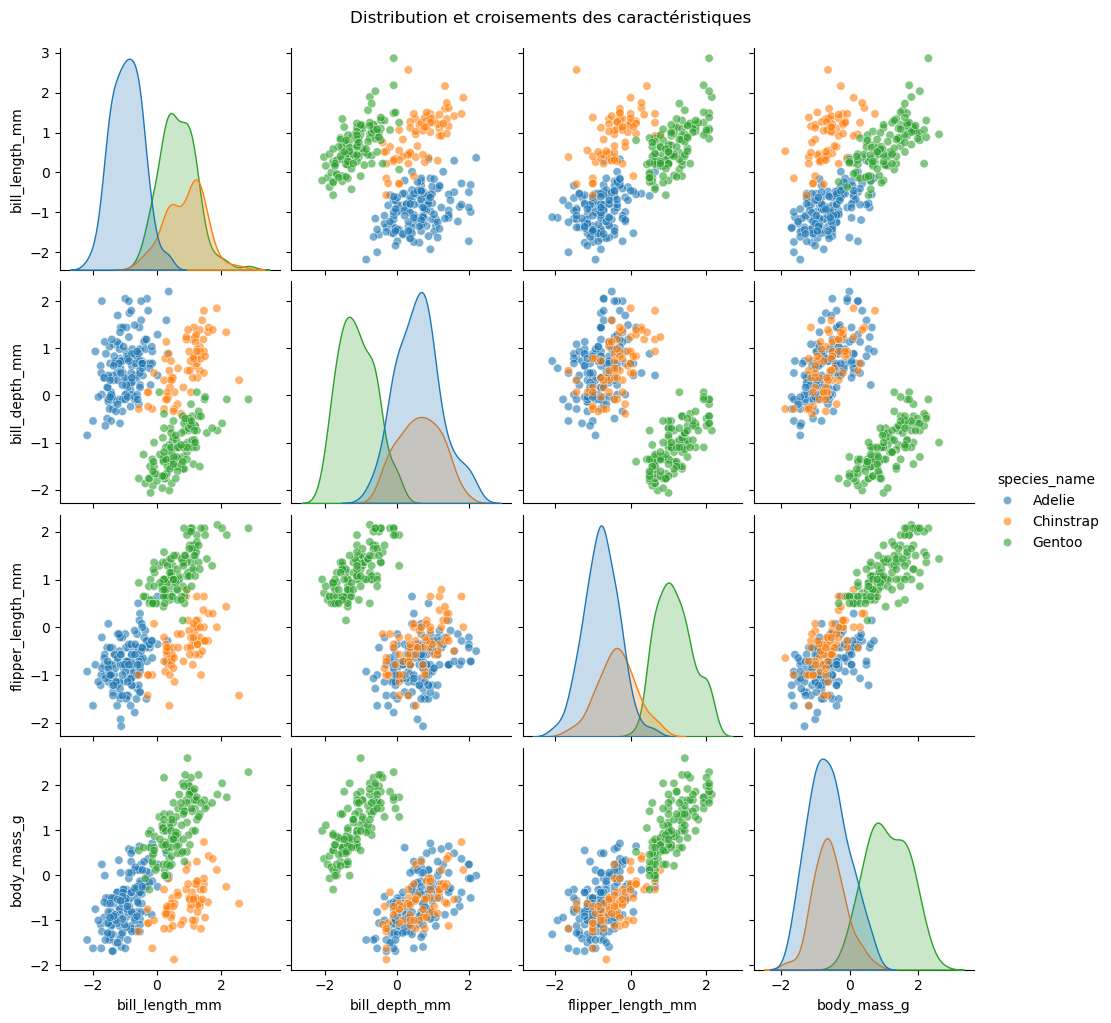


--- Calcul de l'ACP (Variables numériques + catégorielles encodées) ---
Variance expliquée par la Composante 1 : 61.12%
Variance expliquée par la Composante 2 : 20.13%
Total de variance captée par l'ACP : 81.25%


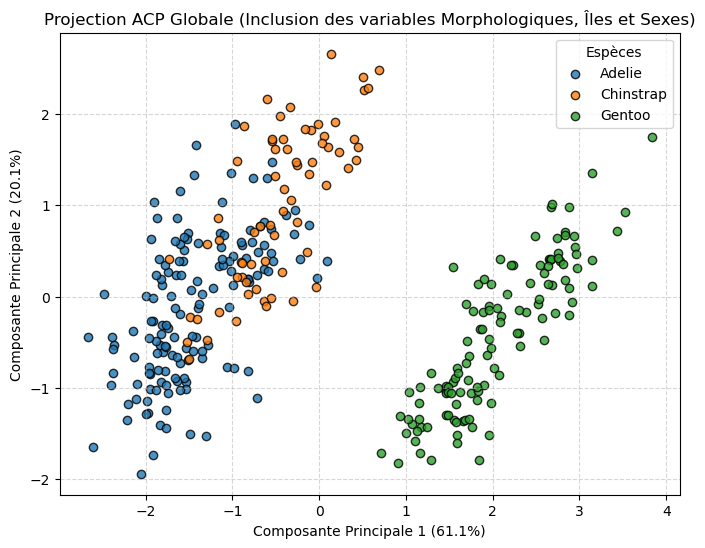


--- Génération de la Heatmap de Corrélation Enrichie ---


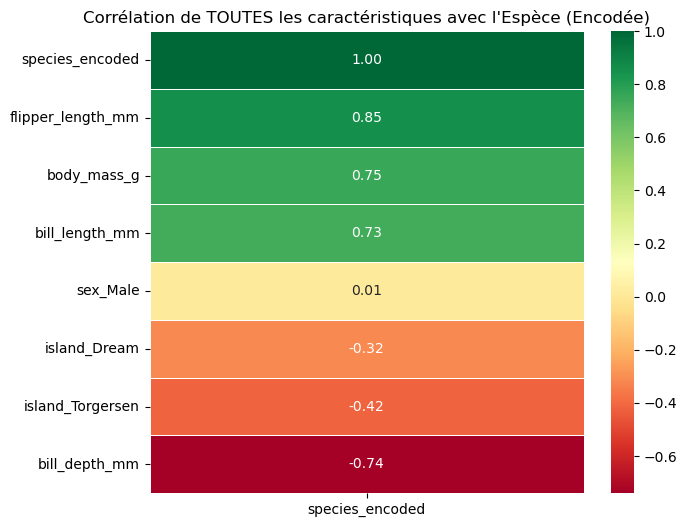


--- Génération des graphiques de répartition Île / Sexe ---


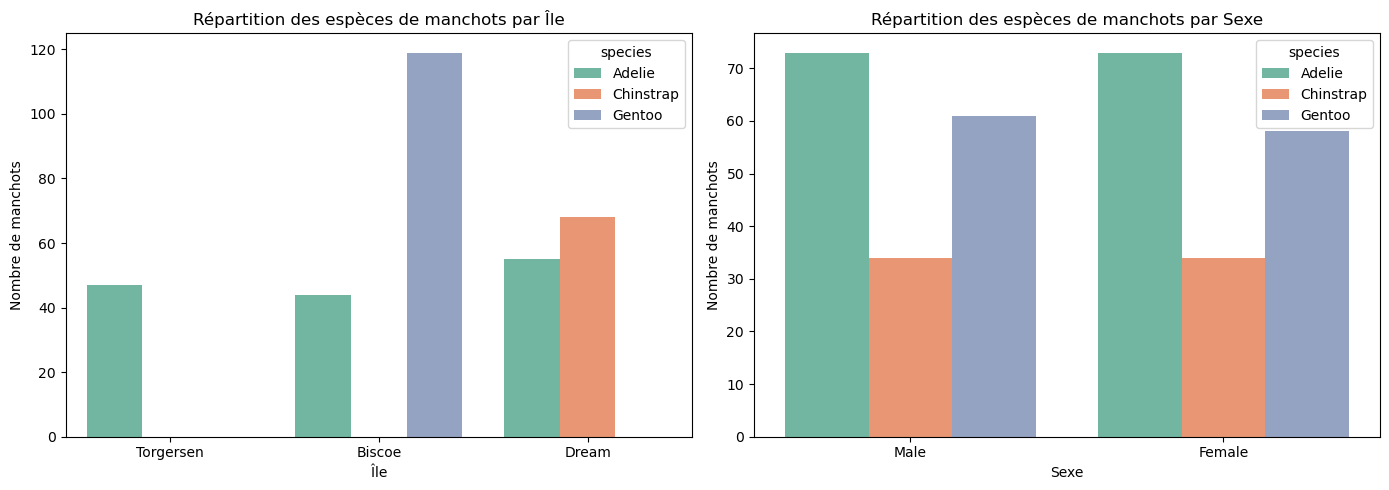

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

# On recrée un DataFrame global propre contenant TOUTES les caractéristiques d'entrées (numériques et encodées)
df_visualisation = pd.DataFrame(X.copy())
df_visualisation["species_name"] = y_raw.values  # Pour l'affichage textuel
df_visualisation["species_encoded"] = y

# Définition des groupes de caractéristiques
features_num = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
features_cat_encoded = ["island_Dream", "island_Torgersen", "sex_Male"]
all_features = features_num + features_cat_encoded

# =====================================================================
# MÉTHODE 1 : VISUALISATION GLOBALE (Pairplot)
# =====================================================================
print("\n--- Génération du Pairplot ---")
# Le pairplot reste idéalement sur le numérique pour être lisible, mais on colore par espèce
sns.pairplot(
    df_visualisation[features_num + ["species_name"]],
    hue="species_name",
    diag_kind="kde",
    plot_kws={"alpha": 0.6},
)
plt.suptitle("Distribution et croisements des caractéristiques", y=1.02)
plt.show()


# =====================================================================
# MÉTHODE 2 : EXTRACTION DE CARACTÉRISTIQUES ENRICHI (ACP complète)
# =====================================================================
print("\n--- Calcul de l'ACP (Variables numériques + catégorielles encodées) ---")
# Cette fois-ci, l'ACP prend TOUT le jeu de données X (numérique scalé + dummies)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X[all_features])

variance_expliquee = pca.explained_variance_ratio_
print(
    f"Variance expliquée par la Composante 1 : {variance_expliquee[0]*100:.2f}%"
)
print(
    f"Variance expliquée par la Composante 2 : {variance_expliquee[1]*100:.2f}%"
)
print(f"Total de variance captée par l'ACP : {sum(variance_expliquee)*100:.2f}%")

# Visualisation de l'ACP
plt.figure(figsize=(8, 6))
for code, conversion in zip([0, 1, 2], le.classes_):
    plt.scatter(
        X_pca[y == code, 0],
        X_pca[y == code, 1],
        label=conversion,
        alpha=0.8,
        edgecolors="k",
    )

plt.xlabel(f"Composante Principale 1 ({variance_expliquee[0]*100:.1f}%)")
plt.ylabel(f"Composante Principale 2 ({variance_expliquee[1]*100:.1f}%)")
plt.title(
    "Projection ACP Globale (Inclusion des variables Morphologiques, Îles et Sexes)"
)
plt.legend(title="Espèces")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# =====================================================================
# MÉTHODE 3 : CORRÉLATION GLOBALE AVEC LA CIBLE (Heatmap enrichie)
# =====================================================================
print("\n--- Génération de la Heatmap de Corrélation Enrichie ---")
# On calcule la corrélation en incluant l'île et le sexe !
corr_c = df_visualisation[all_features + ["species_encoded"]].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_c[["species_encoded"]].sort_values(by="species_encoded", ascending=False),
    annot=True,
    cmap="RdYlGn",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Corrélation de TOUTES les caractéristiques avec l'Espèce (Encodée)")
plt.show()


# =====================================================================
# MÉTHODE 4 : ANALYSE DES VARIABLES CATÉGORIELLES (Nouveau graphique)
# =====================================================================
print("\n--- Génération des graphiques de répartition Île / Sexe ---")
# Pour montrer visuellement l'importance de ces variables catégorielles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique A : Répartition des espèces par Île
sns.countplot(data=df_clean, x="island", hue="species", ax=axes[0], palette="Set2")
axes[0].set_title("Répartition des espèces de manchots par Île")
axes[0].set_xlabel("Île")
axes[0].set_ylabel("Nombre de manchots")

# Graphique B : Répartition des espèces par Sexe
sns.countplot(data=df_clean, x="sex", hue="species", ax=axes[1], palette="Set2")
axes[1].set_title("Répartition des espèces de manchots par Sexe")
axes[1].set_xlabel("Sexe")
axes[1].set_ylabel("Nombre de manchots")

plt.tight_layout()
plt.show()

Remarque : ACP ne semble pas nécessaire pertinente étant donnée que les données semble être bien discriminé selon l'espèce

Analyse des caractéristiques : 
* Espèce Gentoo : Elle est totalement isolée sur l'île de Biscoe (où elle partage l'espace uniquement avec quelques Adelie). Physiquement, l'ACP et le Pairplot montrent que c'est un "gabarit" à part : ce sont les manchots les plus lourds (body_mass_g) et ceux qui ont les nageoires les plus longues (flipper_length_mm).

* Espèce Chinstrap : Elle vit exclusivement sur l'île de Dream. Bien qu'elle partage le même poids et la même taille de nageoires que l'Adelie, elle s'en différencie nettement par son bec : les Chinstrap ont un bec plus long (bill_length_mm) mais plus fin (bill_depth_mm).

* Espèce Adelie : C'est la seule espèce présente sur les 3 îles. Sur l'île de Torgersen, l'identification est immédiate (elle y est seule). Sur les autres îles, elle se distingue des Gentoo par son plus petit gabarit, et des Chinstrap par un bec plus court et plus épais.

Demanière à étoffé notre analyse, Je fait un randome forest pour obtenir la liste des variables qui contribuent le plus.


--- Importance des caractéristiques (Random Forest) ---
  Caractéristique  Importance
   bill_length_mm    0.352837
flipper_length_mm    0.216752
    bill_depth_mm    0.194187
     island_Dream    0.104043
      body_mass_g    0.100066
 island_Torgersen    0.025100
         sex_Male    0.007016


C:\Users\Aorus\AppData\Local\Temp\ipykernel_24220\2474674448.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Caractéristique', data=importance_df, palette='viridis')


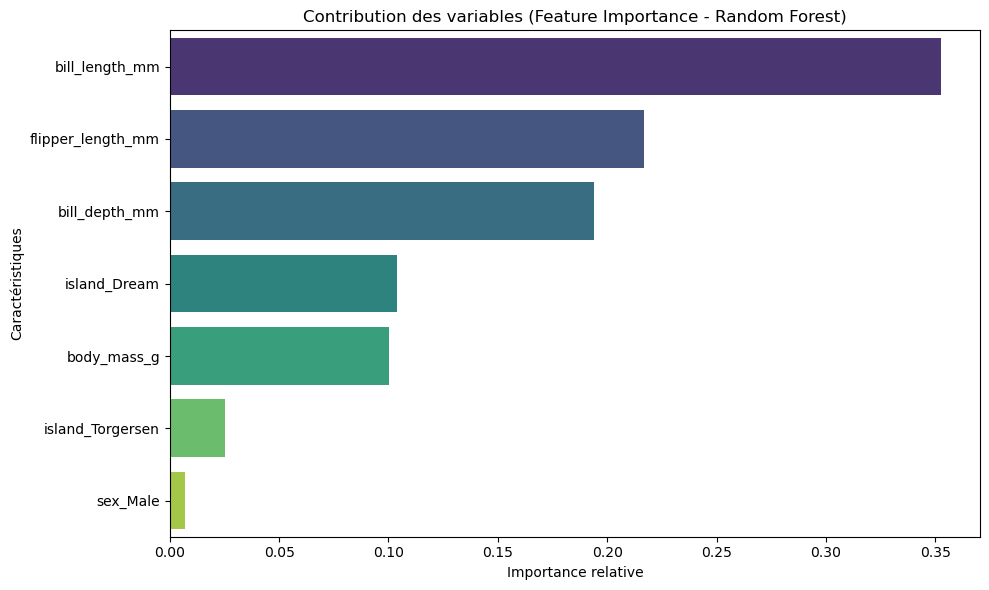

In [6]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Importance des caractéristiques (Random Forest) ---")

# 1. Initialisation et entraînement du modèle
# Utilisation d'un random_state pour la reproductibilité des résultats
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X, y_raw) 

# 2. Extraction de l'importance des variables
feature_importances = rf_clf.feature_importances_

# 3. Création d'un DataFrame pour structurer et trier les résultats
importance_df = pd.DataFrame({
    'Caractéristique': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Affichage textuel des contributions
print(importance_df.to_string(index=False))

# 4. Visualisation graphique
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Caractéristique', data=importance_df, palette='viridis')
plt.title("Contribution des variables (Feature Importance - Random Forest)")
plt.xlabel("Importance relative")
plt.ylabel("Caractéristiques")
plt.tight_layout()
plt.show()

Limites de l'importance prédictive (Random Forest) : Le modèle attribue plus de 76 % de l'importance aux variables continues (morphologie) car son calcul de l'impureté favorise les données permettant des coupures mathématiques multiples. Ce biais sous-évalue les variables catégorielles aux règles déterministes. Par exemple, la présence sur l'île de Torgersen identifie l'espèce Adelie avec une certitude absolue, mais n'obtient qu'un score négligeable de 2,5 % car l'arbre la juge redondante par rapport aux traits physiques globaux. 

Conclusion : L'analyse logique des données (ci-dessus) prime donc sur le score de l'algorithme.

3. Choix des modèles avec leur cross-validation

Expliquation du choix des modèles : 
1. Régression Logistique :
2. KNN : 
3. SVM : 
4. Arbre de décision : 
5. Random forest : 
6. Gradient boosting : 
7. XG Boost : 
8. Réseau de Neurone (MLP) : 

In [7]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# =====================================================================
# 5. CHOIX DES MODÈLES ET CROSS-VALIDATION (8 MODÈLES)
# =====================================================================

modeles = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "K-Neighbors (k-NN)": KNeighborsClassifier(n_neighbors=5),
    "SVM (Noyau RBF)": SVC(kernel="rbf", random_state=42),
    "Arbre de Décision": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XG Boost": XGBClassifier(
        random_state=42, eval_metric="logloss"
    ),  # logloss évite un warning XGBoost
    "Réseau de Neurones (MLP)": MLPClassifier(
        max_iter=1000, random_state=42
    ),  # max_iter élevé pour garantir la convergence
}

print("\n--- Évaluation des modèles par Cross-Validation (Stratified 5-Fold) ---")

resultats_cv = {}

for nom, modele in modeles.items():
    # Rappel : X contient déjà la normalisation et l'encodage des variables catégorielles
    scores = cross_val_score(modele, X, y, cv=5, scoring="accuracy")
    resultats_cv[nom] = scores
    print(f"{nom} :")
    print(f"  -> Scores par sous-ensemble : {scores}")
    print(
        f"  -> Précision Moyenne : {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)"
    )

# Visualisation des performances sous forme de tableau
df_perf = pd.DataFrame(
    {nom: [scores.mean(), scores.std()] for nom, scores in resultats_cv.items()},
    index=["Précision Moyenne", "Écart-type"],
).T

print("\n--- Tableau récapitulatif des performances ---")
print(df_perf)


--- Évaluation des modèles par Cross-Validation (Stratified 5-Fold) ---
Régression Logistique :
  -> Scores par sous-ensemble : [1.         1.         0.98507463 1.         1.        ]
  -> Précision Moyenne : 99.70% (+/- 0.60%)
K-Neighbors (k-NN) :
  -> Scores par sous-ensemble : [0.98507463 0.98507463 0.98507463 1.         0.98484848]
  -> Précision Moyenne : 98.80% (+/- 0.60%)
SVM (Noyau RBF) :
  -> Scores par sous-ensemble : [1.         1.         0.98507463 1.         1.        ]
  -> Précision Moyenne : 99.70% (+/- 0.60%)
Arbre de Décision :
  -> Scores par sous-ensemble : [1.         0.98507463 0.98507463 0.98484848 0.95454545]
  -> Précision Moyenne : 98.19% (+/- 1.49%)
Random Forest :
  -> Scores par sous-ensemble : [1.         0.98507463 0.98507463 0.98484848 1.        ]
  -> Précision Moyenne : 99.10% (+/- 0.73%)
Gradient Boosting :
  -> Scores par sous-ensemble : [1.         0.98507463 0.98507463 1.         0.96969697]
  -> Précision Moyenne : 98.80% (+/- 1.13%)
XG Boost :

Analyse des performances

L'évaluation des 8 méthodes de classification révèle des très bonne performances, les précisions moyennes oscillant toutes entre 98,19 % et 99,70 %. 


1. Les Champions du Benchmark
Trois modèles se partagent la tête du classement avec une précision moyenne identique de 99,70 % et un écart-type très faible (0,60 %) :
* La Régression Logistique
* Le SVM (Noyau RBF)
* Le Réseau de Neurones (MLP)

Le fait qu'un modèle linéaire simple (Régression Logistique) égale des méthode non-linéaires (MLP, SVM RBF) confirme les observations de l'ACP : les frontières de décision séparant les trois espèces de manchots sont majoritairement linéaires.


2. Comportement des modèles d'Ensemble et de Boosting
Les modèles basés sur les arbres (Random Forest : 99,10 %, XGBoost et Gradient Boosting : 98,80 %) affichent également d'excellents scores. 
Cependant, l'introduction d'algorithmes de Boosting n'apporte pas de gain de performance par rapport aux modèles plus simples.

3. Analyse de la robustesse (Écart-type)
L'Arbre de Décision seul obtient la précision la plus faible (98,19 %) et l'écart-type le plus élevé (1,49 %).


             RÉSULTATS DÉTAILLÉS ET MATRICES DE CONFUSION            

--- Rapport détaillé : Régression Logistique ---
              precision    recall  f1-score   support

      Adelie       0.99      1.00      1.00       146
   Chinstrap       1.00      0.99      0.99        68
      Gentoo       1.00      1.00      1.00       119

    accuracy                           1.00       333
   macro avg       1.00      1.00      1.00       333
weighted avg       1.00      1.00      1.00       333


--- Rapport détaillé : K-Neighbors (k-NN) ---
              precision    recall  f1-score   support

      Adelie       0.99      0.98      0.99       146
   Chinstrap       0.96      0.99      0.97        68
      Gentoo       1.00      1.00      1.00       119

    accuracy                           0.99       333
   macro avg       0.98      0.99      0.99       333
weighted avg       0.99      0.99      0.99       333


--- Rapport détaillé : SVM (Noyau RBF) ---
              precision   

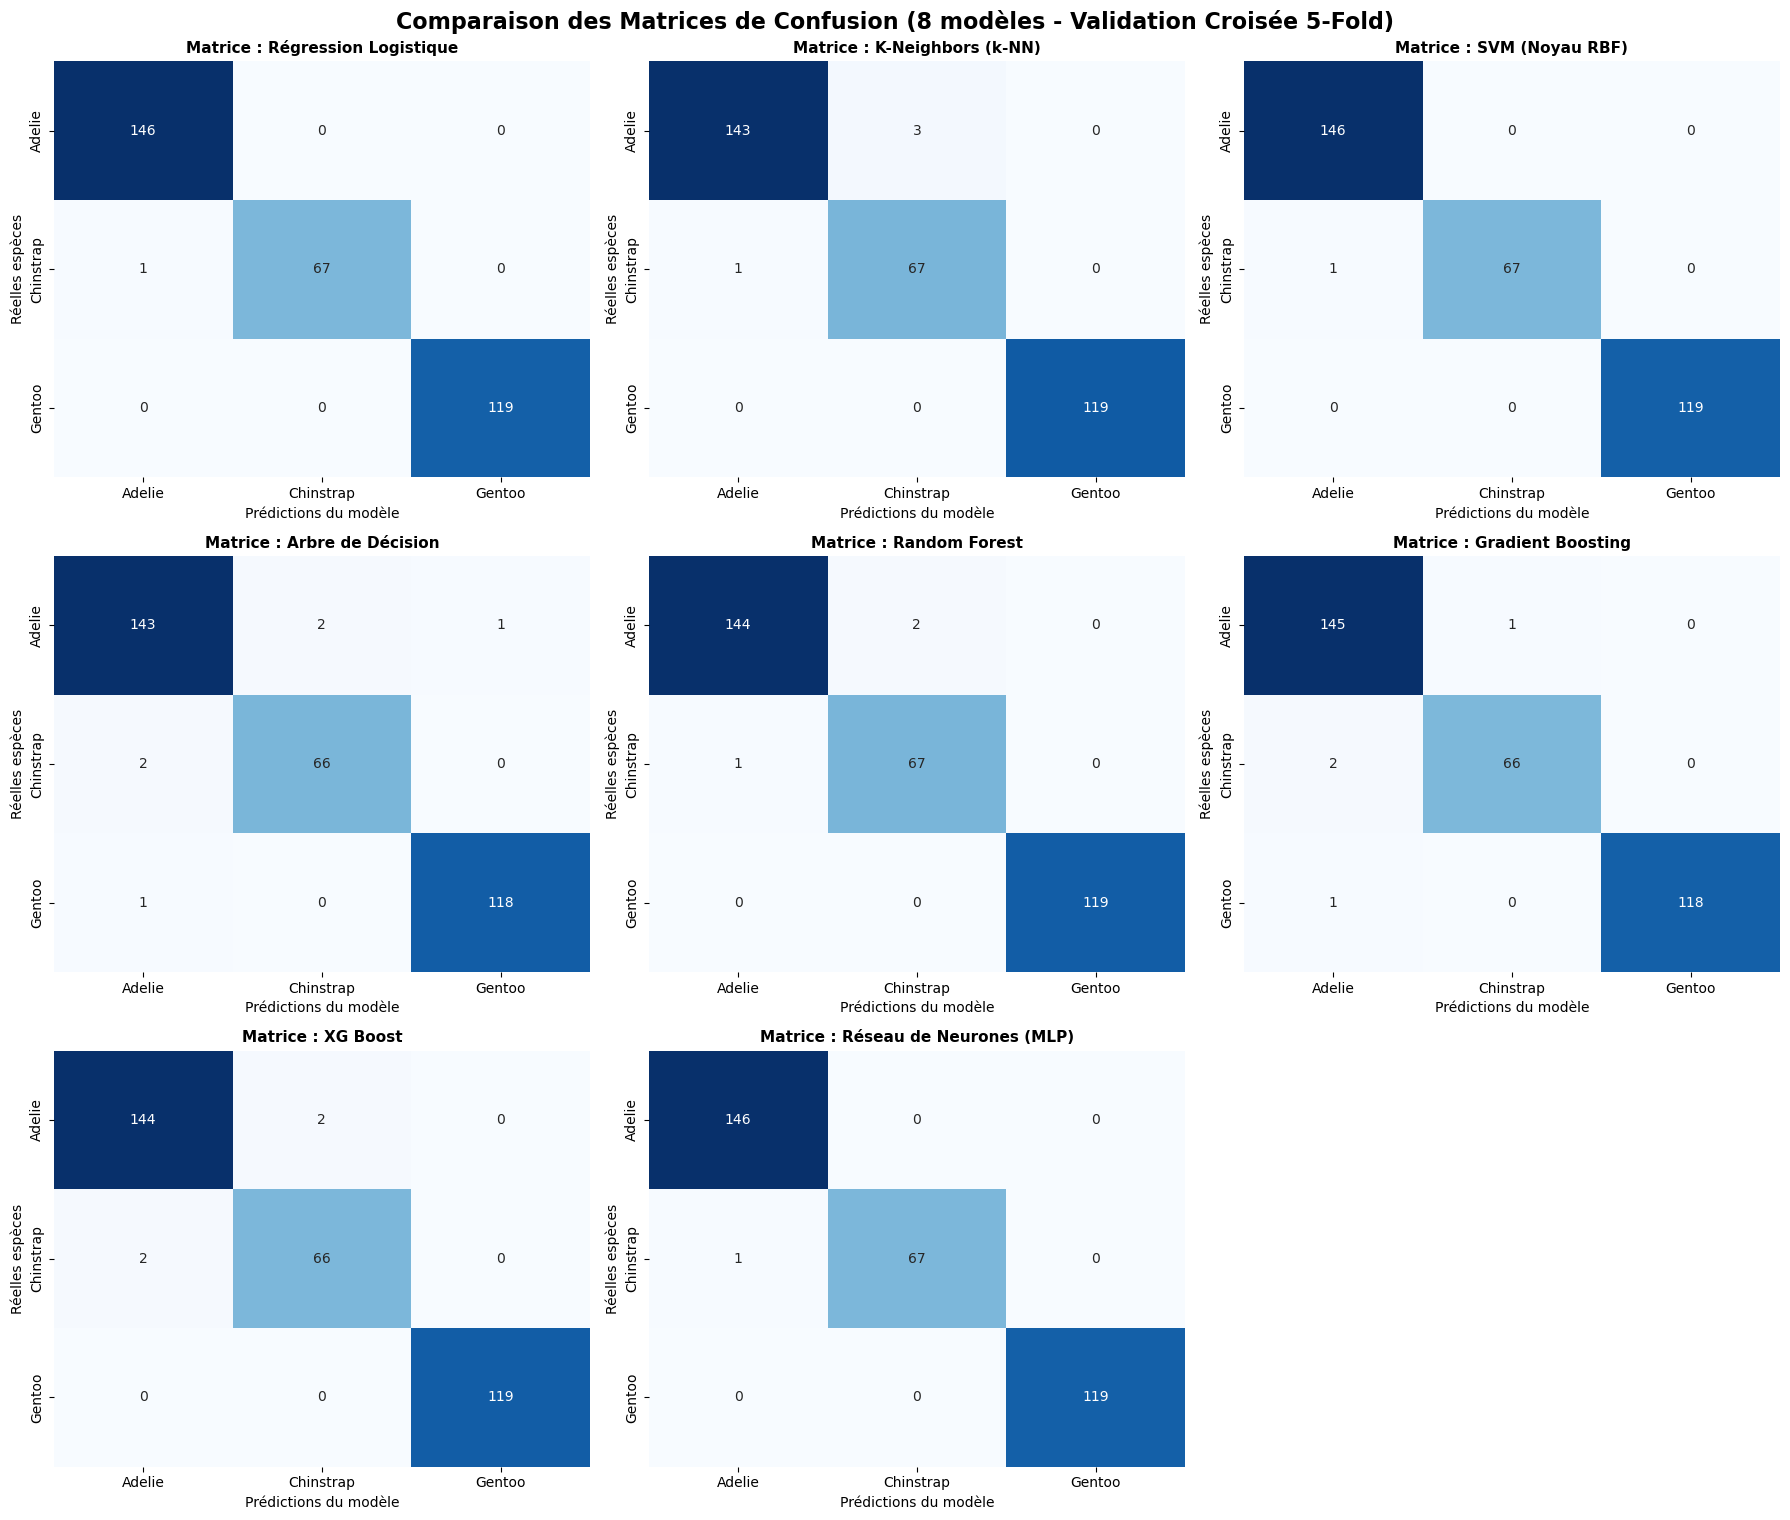

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

# =====================================================================
# 6. RÉSULTATS DÉTAILLÉS & MATRICES DE CONFUSION (8 MODÈLES)
# =====================================================================

print(
    "\n====================================================================="
)
print("             RÉSULTATS DÉTAILLÉS ET MATRICES DE CONFUSION            ")
print(
    "====================================================================="
)

# Configuration de la figure pour afficher les 8 matrices (grille 3x3)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

noms_classes = le.classes_

for i, (nom, modele) in enumerate(modeles.items()):
    y_pred = cross_val_predict(modele, X, y, cv=5)

    print(f"\n--- Rapport détaillé : {nom} ---")
    print(classification_report(y, y_pred, target_names=noms_classes))

    cm = confusion_matrix(y, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=noms_classes,
        yticklabels=noms_classes,
        ax=axes[i],
        cbar=False,
    )
    axes[i].set_title(f"Matrice : {nom}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Prédictions du modèle")
    axes[i].set_ylabel("Réelles espèces")

# On supprime le 9ème graphique vide (index 8) puisque nous n'avons que 8 modèles
fig.delaxes(axes[8])

plt.tight_layout()
plt.suptitle(
    "Comparaison des Matrices de Confusion (8 modèles - Validation Croisée 5-Fold)",
    y=1.01,
    fontsize=16,
    fontweight="bold",
)
plt.show()

Analyse des méthode de classification

L'analyse par classe (calculée sur l'ensemble des prédictions de la cross-validatin) confirme la robustesse des modèles.

1. Régression Logistique : La quasi-linéarité
Sur l'intégralité des 333 manchots (Support), la Régression Logistique n'échoue qu'à une seule reprise :
* Gentoo (119 individus) : Precision et Recall à 1.00. (parfait)
* Le duo Adelie/Chinstrap : Un manchon Chinstrap a été classé en Adélie. Cela fait baisser le Rappel (Recall) des Chinstrap à 0.99 et la Précision des Adelie à 0.99.

Cette performance donne un score arrondi de 1.00 en macro avg (moyenne non pondérée), ce qui prouve que le modèle traite la minorité (Chinstrap, 68 individus) avec une efficacité similaire à celle de la majorité (Adelie, 146 individus).

2. K-Neighbors (KNN) : Une légère sensibilité aux frontières
Le modèle KNN obtient des scores légèrement en deçà (Accuracy globale de 0.99). Ne se basant pas sur des frontières géométriques mais sur la proximité des voisins, il commet un peu plus d'erreurs de recoupement entre les classes Adelie et Chinstrap (la précision des Chinstrap descend à 0.96).

Pipeline scikit-learn. Pour chercher la méthode la plus robuste

--- Lancement de la Pipeline de Recherche Optimale (8 Modèles) ---

                      RÉSULTATS DE LA PIPELINE                       
Meilleure configuration trouvée :
{'classifier': SVC(class_weight='balanced', random_state=42), 'classifier__C': 0.1, 'classifier__kernel': 'linear'}

Précision (Accuracy) finale sur le Test set : 98.51%

Rapport de classification final :
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



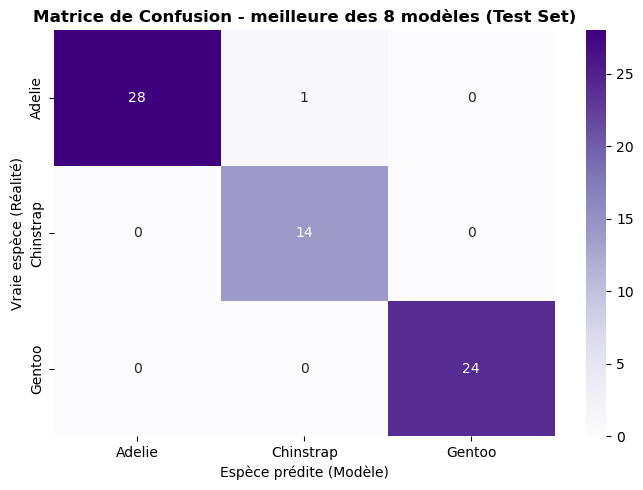

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# =====================================================================
# 1. PRÉPARATION DES DONNÉES ENTRÉES POUR LA PIPELINE
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================================================
# 2. CRÉATION DE LA PIPELINE AVEC PLACEHOLDER
# =====================================================================
pipe = Pipeline([("scaler", StandardScaler()), ("classifier", LogisticRegression())])

# =====================================================================
# 3. GRILLE DE PARAMÈTRES POUR LES 8 MODÈLES
# =====================================================================
param_grid = [
    # 1. Régression Logistique
    {
        "classifier": [LogisticRegression(max_iter=1000, random_state=42)],
        "classifier__C": [0.1, 1, 10],
    },
    # 2. K-Nearest Neighbors
    {
        "classifier": [KNeighborsClassifier()],
        "classifier__n_neighbors": [3, 5, 7, 11],
    },
    # 3. SVM
    {
        "classifier": [SVC(random_state=42, class_weight="balanced")],
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"],
    },
    # 4. Arbre de Décision
    {
        "classifier": [DecisionTreeClassifier(random_state=42)],
        "classifier__max_depth": [4, 6, 8, None],
    },
    # 5. Random Forest
    {
        "classifier": [
            RandomForestClassifier(random_state=42, class_weight="balanced")
        ],
        "classifier__n_estimators": [50, 100, 150],
        "classifier__max_depth": [6, 8, 10],
    },
    # 6. Gradient Boosting
    {
        "classifier": [GradientBoostingClassifier(random_state=42)],
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.05, 0.1],
    },
    # 7. XGBoost
    {
        "classifier": [XGBClassifier(random_state=42, eval_metric="logloss")],
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__max_depth": [3, 5],
    },
    # 8. Réseau de Neurones (MLP)
    {
        "classifier": [MLPClassifier(max_iter=1000, random_state=42)],
        "classifier__hidden_layer_sizes": [(50,), (50, 50)],
        "classifier__alpha": [0.0001, 0.001],
    },
]

# =====================================================================
# 4. CONFIGURATION ET ENTRAÎNEMENT DU GRIDSEARCH GLOBAL
# =====================================================================
print("--- Lancement de la Pipeline de Recherche Optimale (8 Modèles) ---")
grid_search_global = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search_global.fit(X_train, y_train)
best_pipeline = grid_search_global.best_estimator_

print("\n=====================================================================")
print("                      RÉSULTATS DE LA PIPELINE                       ")
print("=====================================================================")
print("Meilleure configuration trouvée :")
print(grid_search_global.best_params_)

# =====================================================================
# 5. ÉVALUATION FINALE SUR L'ENSEMBLE DE TEST
# =====================================================================
y_pred_final = best_pipeline.predict(X_test)
accuracy_final = accuracy_score(y_test, y_pred_final)

print(f"\nPrécision (Accuracy) finale sur le Test set : {accuracy_final*100:.2f}%")
print("\nRapport de classification final :")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

# =====================================================================
# 6. VISUALISATION DE LA MATRICE DE CONFUSION DU MEILLEUR MODÈLE
# =====================================================================
conf_matrix_pipe = confusion_matrix(y_test, y_pred_final)
class_names = le.classes_

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_pipe,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title(
    "Matrice de Confusion - meilleure des 8 modèles (Test Set)",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Vraie espèce (Réalité)")
plt.xlabel("Espèce prédite (Modèle)")
plt.tight_layout()
plt.show()

Analyse de la Pipeline Finale et du "meilleur modèle"

L'optimisation globale par GridSearch sur l'ensemble des 8 architectures renvoie le Support Vector Machine (SVC) comme meilleur modèle avec un noyau linéaire et une régularisation C = 0.1.

Points clés du résultat :
* Généralisation validée : Le modèle obtient une précision de 98,51 % sur le jeu de test indépendant (67 individus), prouvant l'absence de surapprentissage (overfitting).
* Robustesse de la frontière linéaire : Le choix d'un noyau linéaire (kernel='linear') par l'algorithme confirme définitivement la structure géométrique "simple" observée lors de l'ACP. Les hyperplans rectilignes suffisent à séparer efficacement les groupes.
* L'erreur : Les métriques par classe (support) montrent que le modèle commet une seule erreur d'aiguillage sur l'ensemble de test : un manchot Adelie a été classé à comme Chinstrap. C'est pourquoi le rappel (recall) d'Adelie descend à 0,97 et la précision de Chinstrap se stabilise à 0,93. 

La macro-moyenne (macro avg) de 0,98 pour le F1-score atteste d'une efficacité parfaitement équilibrée entre les trois espèces de manchots.